# DecoupleR

Test DecoupleR annotation

In [1]:
import scanpy as sc
import decoupler as dc
import pandas as pd
import anndata as ad

# 1. Load Single Cell Data
adata = ad.io.read_h5ad('../data/humancellatlas/5f29c29a-51c6-435c-8ff0-2b2a9d05ebee/BL_standard_design_annotated.h5ad')

# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

# Limit adata for tests to 5.000
adata = adata[:5000]

print(adata)

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


View of AnnData object with n_obs × n_vars = 3000 × 25825
    obs: 'n_genes', 'Channel', 'n_counts', 'percent_mito', 'scale', 'Group', 'leiden_labels', 'Donor', 'doublet_score', 'pred_dbl', 'anno', 'scumi-annotation'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'Groups', 'PCs', 'W_pca_harmony', 'c2gid', 'df_qcplot', 'genome', 'gncells', 'leiden_resolution', 'log1p', 'modality', 'ncells', 'norm_count', 'pca', 'pca_features', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'de_res', 'gmeans', 'gstds', 'means', 'partial_sum'


In [ ]:
import json

with open('../scumi-dev/R/marker_gene/human_pbmc_marker.json', 'r', encoding='utf-8') as file:
            marker_dict = json.load(file)

marker_df = pd.DataFrame.from_dict(marker_dict)

print(marker_df.head())

In [2]:
import json
import pandas as pd

# 1. JSON-Datei einlesen
with open('../scumi-dev/R/marker_gene/human_pbmc_marker.json', 'r', encoding='utf-8') as file:
    marker_dict = json.load(file)

# 2. Daten in eine flache Liste von Dicts für das Long-Format transformieren
rows = []
for cell_type, genes in marker_dict.items():
    for gene_entry in genes:
        # Suffix (+ oder -) extrahieren und bereinigen
        if gene_entry.endswith('+'):
            gene = gene_entry[:-1]
            weight = 1
        elif gene_entry.endswith('-'):
            gene = gene_entry[:-1]
            weight = -1
        else:
            gene = gene_entry
            weight = 1  # Fallback, falls kein Suffix vorhanden ist
            
        rows.append({
            'source': cell_type,  # decoupleR erwartet meistens 'source' für die Gengruppen/Zelltypen
            'target': gene,       # decoupleR erwartet meistens 'target' für die Gene
            'weight': weight      # Optionale Gewichtung (Mode of Regulation)
        })

# 3. DataFrame erstellen
marker_df = pd.DataFrame(rows)

# 4. Ergebnis überprüfen
print(marker_df.head(15))

              source target  weight
0        CD4+ T cell   CD3D       1
1        CD4+ T cell   CD3E       1
2        CD4+ T cell   CD3G       1
3        CD4+ T cell   TRAC       1
4        CD4+ T cell    CD4       1
5        CD4+ T cell   TCF7       1
6        CD4+ T cell   CD27       1
7        CD4+ T cell   IL7R       1
8        CD4+ T cell   CD8A      -1
9        CD4+ T cell   CD8B      -1
10       CD4+ T cell   GNLY      -1
11       CD4+ T cell   NKG7      -1
12       CD4+ T cell   CST7      -1
13  Cytotoxic T cell   CD3D       1
14  Cytotoxic T cell   CD3E       1


In [6]:
dc.op.show_resources()

,name,license
0,Adhesome,commercial
1,Almen2009,commercial
2,Baccin2019,academic
3,CORUM_Funcat,academic
4,CORUM_GO,academic
...,...,...
76,iTALK,academic
77,kinase.com,non_profit
78,scConnect,commercial
79,scConnect_complex,commercial


In [4]:
# Load marker genes
marker_df = dc.op.resource("PanglaoDB", organism="human") #PanglaoDB#CellMarker

# Format marker genes
marker_df = marker_df.rename(columns={"cell_type": "source", "genesymbol": "target"})
marker_df = marker_df[["source", "target"]]
marker_df = marker_df.drop_duplicates(subset=['source', 'target'])

print(marker_df.head())

          source  target
                        
0    Hepatocytes    A1CF
1     Germ cells  A2APA5
2  Bergmann glia     A2M
3     Mast cells  A3FIN4
4     Mast cells  A4GALT


In [3]:
import scipy.sparse as sp

# 1. Sicherstellen, dass adata.X im korrekten CSR-Format vorliegt
if not isinstance(adata.X, sp.csr_matrix):
    print("Konvertiere Matrix zu CSR...")
    adata.X = sp.csr_matrix(adata.X)

# 2. Sicherstellen, dass keine NaN-Werte in der Referenzdatenbank sind
# (PanglaoDB hat manchmal leere Zeilen bei den Genen)
marker_df_clean = marker_df.dropna(subset=['source', 'target'])

# 3. Wichtig: Filtere PanglaoDB, sodass NUR Gene übrig bleiben, die AUCH in deinen Daten sind.
# Das verhindert, dass der Algorithmus mit leeren Vektoren abstürzt.
genes_in_data = set(adata.var_names)
marker_df_clean = marker_df_clean[marker_df_clean['target'].isin(genes_in_data)]

print(f"Schnittmenge der Gene: {len(marker_df_clean['target'].unique())} Gene stimmen überein.")

Schnittmenge der Gene: 83 Gene stimmen überein.


In [6]:
# Checken, was in deinen Single-Cell Daten steht
print("Deine Gen-Namen (Auszug):", adata.var_names[:5].tolist())

# Checken, was in PanglaoDB steht
print("PanglaoDB Gen-Namen (Auszug):", marker_df['target'].head().tolist())

Deine Gen-Namen (Auszug): ['MIR1302-2HG', 'AL627309.1', 'AL627309.3', 'AL627309.4', 'AL669831.2']
PanglaoDB Gen-Namen (Auszug): ['A1CF', 'A2APA5', 'A2M', 'A3FIN4', 'A4GALT']


In [7]:
# 1. Gen-Namen bereinigen (Alles nach dem Punkt entfernen und in Großbuchstaben umwandeln)
# Aus 'AL627309.1' wird 'AL627309'
clean_names = [gene.split('.')[0].upper() for gene in adata.var_names]

# Überschneidungen prüfen, bevor wir die Namen permanent ändern
overlap_test = set(clean_names).intersection(set(marker_df['target']))
print(f"Schnittmenge NACH der Bereinigung: {len(overlap_test)} Gene stimmen überein.")

# 2. Wenn die Schnittmenge jetzt größer als 0 ist, weisen wir die neuen Namen zu
if len(overlap_test) > 0:
    adata.var_names = clean_names
    # Wichtig: Falls es durch das Abschneiden Duplikate gibt (z.B. GEN.1 und GEN.2 werden beide zu GEN),
    # müssen wir diese einzigartig machen, sonst meckert Scanpy.
    adata.var_names_make_unique()
else:
    print("Warnung: Immer noch keine Übereinstimmung. Deine Daten nutzen vermutlich eine ganz andere Nomenklatur.")

Schnittmenge NACH der Bereinigung: 3874 Gene stimmen überein.


In [4]:
# ORA ausführen
# Wir testen, welche Zelltyp-Signaturen in welchen Zellen überrepräsentiert sind
#dc.run_ora(
dc.mt.ora(
    data=adata,
    net=marker_df,
    #source='cell_type',    # Die Spalte mit den Zelltypen im Netzwerk
    #target='genesymbol',   # Die Spalte mit den Genen im Netzwerk
    n_up=300,                        # Top 300 Gene pro Cluster für den Test nutzen
    n_bg=int(adata.shape[1]), # Setzt den Hintergrund exakt auf deine 25825 Gene!
    verbose=True,
    raw=False          # Nutzt adata.X
)

2026-06-14 22:38:02 | [INFO] ora - Running ora
2026-06-14 22:38:02 | [INFO] Extracted omics mat with 3000 rows (observations) and 25825 columns (features)
2026-06-14 22:38:02 | [WARNING] 8444 features of mat are empty, they will be removed
2026-06-14 22:38:02 | [INFO] Network has 83 unique features and 10 unique sources
2026-06-14 22:38:02 | [INFO] ora - calculating 10 scores across 3000 observations with n_up=300, n_bm=0, n_bg=25825
100%|██████████████████████████████████████████████| 3000/3000 [00:08<00:00, 345.86it/s]
2026-06-14 22:38:11 | [INFO] ora - adjusting p-values by FDR
2026-06-14 22:38:11 | [INFO] ora - done
/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/decoupler/mt/_run.py:33: ImplicitModificationWarning: Setting element `.obsm['score_ora']` of view, initializing view as actual.
  data.obsm[f"score_{name}"] = es


In [5]:
print(adata)

AnnData object with n_obs × n_vars = 3000 × 25825
    obs: 'n_genes', 'Channel', 'n_counts', 'percent_mito', 'scale', 'Group', 'leiden_labels', 'Donor', 'doublet_score', 'pred_dbl', 'anno', 'scumi-annotation'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'Groups', 'PCs', 'W_pca_harmony', 'c2gid', 'df_qcplot', 'genome', 'gncells', 'leiden_resolution', 'log1p', 'modality', 'ncells', 'norm_count', 'pca', 'pca_features', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'score_ora', 'padj_ora'
    varm: 'de_res', 'gmeans', 'gstds', 'means', 'partial_sum'


In [6]:
print(type(adata.obsm['score_ora']))

<class 'pandas.core.frame.DataFrame'>


In [14]:
# Erstellt eine AnnData-Objekt-Kopie nur für die Scores, um sie leichter zu plotten
#acts = dc.get_acts(adata, obsm_key='ora_estimate')
#acts = dc.pp.extract(adata, layer='score_ora')

# Beispiel: Plotten der Aktivität für "T cells" und "B cells" (Namen an deinen Daten anpassen!)
sc.pl.umap(adata.obsm['score_ora'], color=['T cells', 'B cells'], cmap='开放_RdBu_r', vcenter=0)

AttributeError: 'DataFrame' object has no attribute '_sanitize'

/tmp/ipykernel_179674/2856113674.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = df.groupby('cluster').mean()


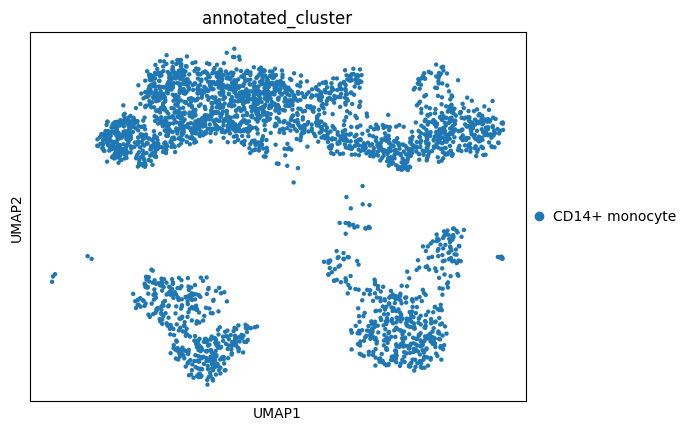

In [7]:
# Berechne den mittleren ORA-Score pro bestehendem Cluster (z.B. 'louvain' oder 'leiden')
#df = dc.get_acts(adata, obsm_key='ora_estimate').to_df()
df = adata.obsm['score_ora']
df['cluster'] = adata.obs['leiden_labels'] # oder 'leiden'
mean_df = df.groupby('cluster').mean()

# Für jeden Cluster den Zelltyp mit dem höchsten mittleren Score finden
cluster_to_celltype = mean_df.idxmax(axis=1).to_dict()

# Map die Annotationen zurück auf die Zellen
adata.obs['annotated_cluster'] = adata.obs['leiden_labels'].map(cluster_to_celltype)

# Finaler Plot
sc.pl.umap(adata, color='annotated_cluster')

In [8]:
classes = set(adata.obs['annotated_cluster'])
print(classes)

{'CD14+ monocyte'}


In [17]:
classes = set(adata.obs['anno'])
print(classes)

{'Memory B cells', 'HSCs', 'CD4+ naive T cells', 'cDCs', 'Plasma cells', 'Tregs', 'Cytotoxic T cells', 'CD14+ monocytes', 'CD8+ naive T cells', 'pDCs', 'Megakaryocytes', 'T helper cells', 'CD16+ monocytes', 'NK cells', 'Naive B cells'}


In [26]:
leiden_labels = set(adata.obs['leiden_labels'])
print(leiden_labels)

{'4', '9', '18', '7', '2', '12', '8', '16', '15', '14', '6', '10', '11', '5', '19', '17', '20', '3', '13', '1'}


In [25]:
print(marker_df)

                          source   target
                                         
0                    Hepatocytes     A1CF
1                     Germ cells   A2APA5
2                  Bergmann glia      A2M
3                     Mast cells   A3FIN4
4                     Mast cells   A4GALT
...                          ...      ...
8206  Adipocyte progenitor cells   ZNF521
8207                  Germ cells    ZNRF4
8208                  Germ cells    ZPBP2
8209                     Neurons  ZRSR2P1
8210        Embryonic stem cells  ZSCAN10

[8190 rows x 2 columns]


## 2. Versuch - nur mit Docs arbeiten

In [1]:
import scanpy as sc
import decoupler as dc
import pandas as pd
import anndata as ad

# 1. Load Single Cell Data
adata = ad.io.read_h5ad('../data/humancellatlas/5f29c29a-51c6-435c-8ff0-2b2a9d05ebee/BL_standard_design_annotated.h5ad')

# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

# Limit adata for tests to 5.000
#adata = adata[:5000]

print(adata)

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 3000 × 25825
    obs: 'n_genes', 'Channel', 'n_counts', 'percent_mito', 'scale', 'Group', 'leiden_labels', 'Donor', 'doublet_score', 'pred_dbl', 'anno', 'scumi-annotation'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'Groups', 'PCs', 'W_pca_harmony', 'c2gid', 'df_qcplot', 'genome', 'gncells', 'leiden_resolution', 'log1p', 'modality', 'ncells', 'norm_count', 'pca', 'pca_features', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'de_res', 'gmeans', 'gstds', 'means', 'partial_sum'


In [2]:
markers = dc.op.resource("PanglaoDB", organism="human")

# Filter by canonical_marker and human
markers = markers[
    markers["human"].astype(bool)
    & markers["canonical_marker"].astype(bool)
    & (markers["human_sensitivity"].astype(float) > 0.5)
]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

# Format
markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]
print(markers)

                                source   target
                                               
18    Pulmonary alveolar type II cells    ABCA3
90                         Enterocytes    ACSL5
105                Smooth muscle cells    ACTA2
113                Smooth muscle cells    ACTG2
114                Myoepithelial cells    ACTG2
...                                ...      ...
8092                 Endothelial cells      VWF
8101          Luminal epithelial cells    WFDC2
8102                      Ductal cells    WFDC2
8129                         Podocytes      WT1
8197                   Ependymal cells  ZMYND10

[690 rows x 2 columns]


### Scoring

In [5]:
markers = marker_df
markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})

In [6]:
dc.mt.ulm(data=adata, net=markers, tmin=3)
print(adata.obsm["score_ulm"])

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/decoupler/mt/_run.py:33: ImplicitModificationWarning: Setting element `.obsm['score_ulm']` of view, initializing view as actual.
  data.obsm[f"score_{name}"] = es


                          B cell  CD14+ monocyte  CD16+ monocyte  CD4+ T cell  \
barcodekey                                                                      
BL1_1-AAACCTGAGAGGGATA -0.690621       -4.976965       -4.808810     0.994234   
BL1_1-AAACCTGAGCACCGCT -0.483123       -1.378464       -2.508724    -3.555224   
BL1_1-AAACCTGCACGAAACG -0.600784       -5.300408       -5.176935    -0.194972   
BL1_1-AAACCTGCAGGGTACA -0.614995       -4.324205       -3.072737    -3.177314   
BL1_1-AAACCTGGTTAAAGAC -0.684360        7.731838       -0.262529    -0.215180   
...                          ...             ...             ...          ...   
BL1_1-GCAGTTAAGATGTCGG -0.477937       -5.008541       -4.928994     9.369083   
BL1_1-GCAGTTAAGGTGACCA -0.699018       -4.776196       -4.599881     7.841774   
BL1_1-GCAGTTAAGTTAGCGG -0.679298       -2.200515       -1.972084     4.670294   
BL1_1-GCAGTTACAAATCCGT -0.535846       -5.678400       -5.590617     8.393461   
BL1_1-GCAGTTACAAGCTGAG -0.73

In [7]:
score = dc.pp.get_obsm(adata, key="score_ulm")
print(score)

AnnData object with n_obs × n_vars = 3000 × 10
    obs: 'n_genes', 'Channel', 'n_counts', 'percent_mito', 'scale', 'Group', 'leiden_labels', 'Donor', 'doublet_score', 'pred_dbl', 'anno', 'scumi-annotation'
    uns: 'Channels', 'Groups', 'PCs', 'W_pca_harmony', 'c2gid', 'df_qcplot', 'genome', 'gncells', 'leiden_resolution', 'log1p', 'modality', 'ncells', 'norm_count', 'pca', 'pca_features', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'score_ulm', 'padj_ulm'


In [8]:
sc.pl.umap(score, color=["NK cells", "leiden_labels"], cmap="RdBu_r")
sc.pl.violin(score, keys=["NK cells"], groupby="leiden_labels", rotation=90)

KeyError: 'Could not find key NK cells in .var_names or .obs.columns.'

<Figure size 1455.6x480 with 0 Axes>

In [9]:
df = dc.tl.rankby_group(adata=score, groupby="leiden_labels", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]
print(df)

    group reference                         name       stat  meanchange  \
1      10      rest             Cytotoxic T cell  12.435198    4.396898   
8      10      rest                  CD4+ T cell   1.270895    0.441370   
9      10      rest          Natural killer cell   0.338771    0.096835   
10      6      rest          Natural killer cell  38.193125    6.899723   
12      6      rest  Plasmacytoid dendritic cell  21.876851    2.366512   
..    ...       ...                          ...        ...         ...   
192    17      rest               CD16+ monocyte   1.504344    2.074671   
194    17      rest  Plasmacytoid dendritic cell   1.052448    1.158763   
195    17      rest               Dendritic cell   0.994175    1.273564   
198    17      rest               CD14+ monocyte   0.239326    0.740235   
199    17      rest          Natural killer cell   0.002043    0.004317   

              pval           padj  
1     6.174148e-27   3.087074e-26  
8     2.051733e-01   2.2797

In [10]:
n_ctypes = 3
ctypes_dict = df.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()
print(ctypes_dict)

{'1': ['CD4+ T cell', 'Cytotoxic T cell'], '10': ['Cytotoxic T cell', 'CD4+ T cell', 'Natural killer cell'], '11': ['Cytotoxic T cell'], '12': ['CD4+ T cell', 'Cytotoxic T cell'], '13': ['CD16+ monocyte', 'Dendritic cell', 'CD14+ monocyte'], '14': ['Dendritic cell', 'CD14+ monocyte', 'Plasmacytoid dendritic cell'], '15': ['Natural killer cell', 'Plasma cell', 'Plasmacytoid dendritic cell'], '16': ['Plasmacytoid dendritic cell', 'Dendritic cell', 'CD16+ monocyte'], '17': ['Plasma cell', 'B cell', 'CD16+ monocyte'], '18': ['Megakaryocyte', 'Plasmacytoid dendritic cell', 'Plasma cell'], '19': ['CD4+ T cell', 'Cytotoxic T cell', 'Plasmacytoid dendritic cell'], '2': ['CD14+ monocyte', 'Dendritic cell', 'Plasma cell'], '20': ['Plasmacytoid dendritic cell', 'Dendritic cell', 'CD16+ monocyte'], '3': ['CD4+ T cell', 'Cytotoxic T cell'], '4': ['B cell', 'CD16+ monocyte', 'Dendritic cell'], '5': ['Cytotoxic T cell', 'CD4+ T cell'], '6': ['Natural killer cell', 'Plasmacytoid dendritic cell', 'Plas

/tmp/ipykernel_163616/3726861848.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctypes_dict = df.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()


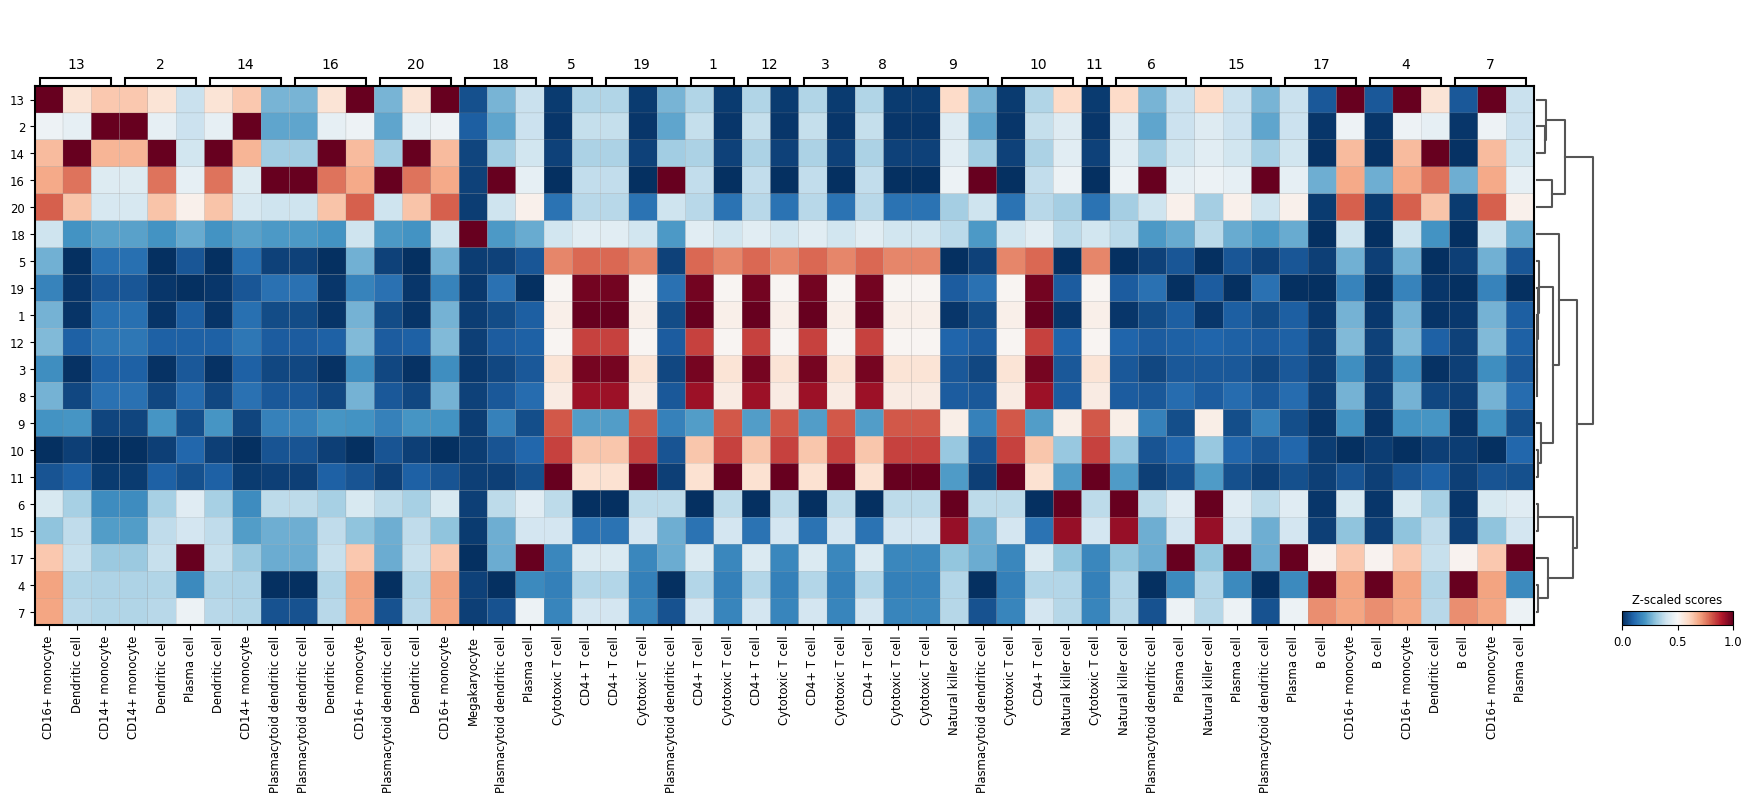

In [11]:
sc.pl.matrixplot(
    adata=score,
    var_names=ctypes_dict,
    groupby="leiden_labels",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)

In [12]:
sc.pl.violin(
    adata=score,
    keys=["T cells", "B cells", "Platelets", "Monocytes", "NK cells"],
    groupby="leiden_labels",
    rotation=90,
)

KeyError: "Could not find keys ['T cells', 'B cells', 'Platelets', 'Monocytes', 'NK cells'] in columns of `adata.obs` or in adata.var_names."

In [13]:
dict_ann = df[df["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
print(dict_ann)

{'10': 'Cytotoxic T cell', '6': 'Natural killer cell', '11': 'Cytotoxic T cell', '2': 'CD14+ monocyte', '3': 'CD4+ T cell', '1': 'CD4+ T cell', '7': 'B cell', '5': 'Cytotoxic T cell', '9': 'Cytotoxic T cell', '13': 'CD16+ monocyte', '12': 'CD4+ T cell', '4': 'B cell', '8': 'CD4+ T cell', '15': 'Natural killer cell', '16': 'Plasmacytoid dendritic cell', '14': 'Dendritic cell', '18': 'Megakaryocyte', '19': 'CD4+ T cell', '20': 'Plasmacytoid dendritic cell', '17': 'Plasma cell'}


/tmp/ipykernel_163616/2508462774.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dict_ann = df[df["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()


In [14]:
# Update cats
adata.obs["leiden_labels"] = adata.obs["leiden_labels"].cat.rename_categories(dict_ann)

ValueError: Categorical categories must be unique

In [15]:
# WICHTIG: Zuerst zu category konvertieren, falls noch nicht geschehen
import pandas as pd

if not isinstance(adata.obs["leiden_labels"].dtype, pd.CategoricalDtype):
    print("Konvertiere leiden_labels zu category...")
    adata.obs["leiden_labels"] = adata.obs["leiden_labels"].astype('category')

# Jetzt können wir rename_categories nutzen
dict_ann_complete = {cat: dict_ann.get(cat, cat) for cat in adata.obs["leiden_labels"].cat.categories}

print("Mapping:")
print(dict_ann_complete)

adata.obs["leiden_labels"] = adata.obs["leiden_labels"].cat.rename_categories(dict_ann_complete)

print("Neue Label:")
print(adata.obs["leiden_labels"].unique())

Mapping:
{'1': 'CD4+ T cell', '2': 'CD14+ monocyte', '3': 'CD4+ T cell', '4': 'B cell', '5': 'Cytotoxic T cell', '6': 'Natural killer cell', '7': 'B cell', '8': 'CD4+ T cell', '9': 'Cytotoxic T cell', '10': 'Cytotoxic T cell', '11': 'Cytotoxic T cell', '12': 'CD4+ T cell', '13': 'CD16+ monocyte', '14': 'Dendritic cell', '15': 'Natural killer cell', '16': 'Plasmacytoid dendritic cell', '17': 'Plasma cell', '18': 'Megakaryocyte', '19': 'CD4+ T cell', '20': 'Plasmacytoid dendritic cell'}


ValueError: Categorical categories must be unique

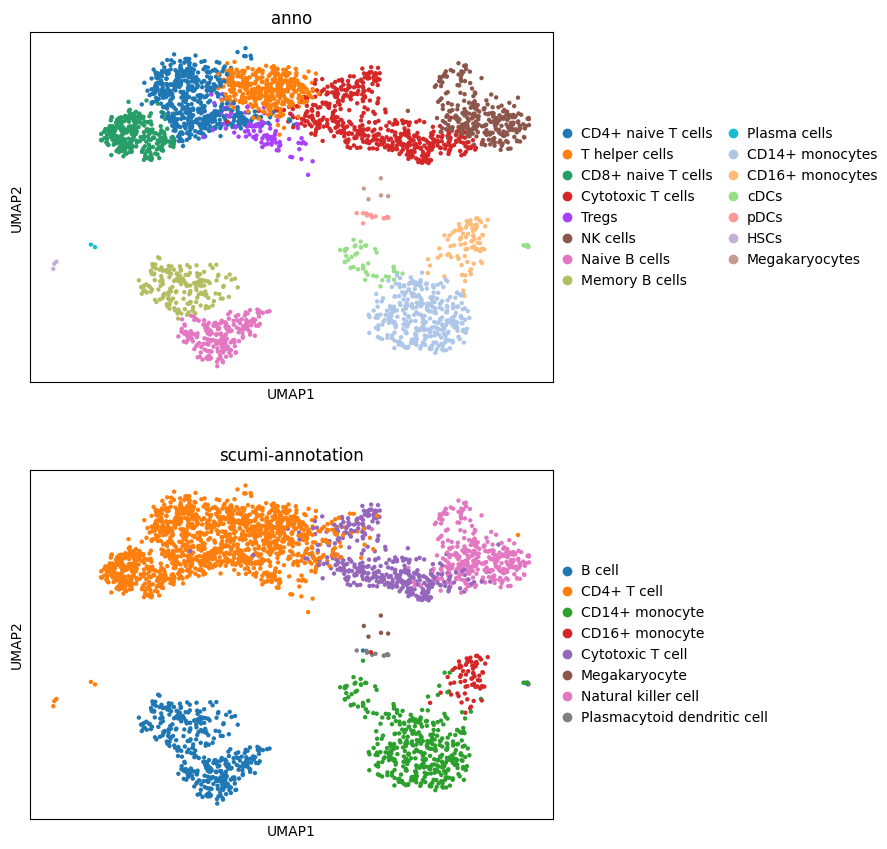

In [16]:
sc.pl.umap(
    adata=adata,
    color=["anno", "scumi-annotation"], #leiden_labels
    ncols=1,
)

In [41]:
print(type(adata.obs['anno']))

<class 'pandas.core.series.Series'>
